# DIFFUSION MODELS

In [1]:
%run init_notebook.py

import torch.nn as nn
from torchvision.datasets import FashionMNIST, QMNIST, KMNIST
from torch.utils.data import DataLoader, TensorDataset
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
import time
import json
from tqdm import tqdm  # import the class directly
from datetime import timedelta

import torchaudio.transforms as T
from src.dataset import NSynth
import torch
from src.diffusion import *
from src.utils.models import adjust_shape, compute_magnitude_and_phase, compute_magnitude_and_phase_sin_cos
import math

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

root = r"C:\Users\Articuno\Desktop\TFG-MUSICAL\data\models\diffusion"
paths = {
    'minst' : {
        'root': root + r"\minst",
        'model': root + r"\minst\model.pth",
        'object': root + r"\minst\object.pth",
        'config': root + r"\minst\config.json",
        'scheduler': root + r"\minst\scheduler.pth",
        'checkpoint': root + r"\minst\checkpoint.pth",
        'dataset' : r"C:\Users\Articuno\Desktop\TFG-info\data\mnist"
    },
    'audio' : {
        'root': root + r"\audio",
        'model': root + r"\audio\model.pth",
        'config': root + r"\audio\config.json",
        'object': root + r"\audio\object.pth",
        'scheduler': root + r"\audio\scheduler.pth",
        'checkpoint': root + r"\audio\checkpoint.pth"
    },
    'latent' : {
        'root': root + r"\latent",
        'model': root + r"\latent\model.pth",
        'object': root + r"\latent\object.pth",
        'config': root + r"\latent\config.json",
        'scheduler': root + r"\latent\scheduler.pth",
        'checkpoint': root + r"\latent\checkpoint.pth",
        'dataset_training' : r"C:\Users\Articuno\Desktop\TFG-MUSICAL\data\models\diffusion\latent\dataset\training.pt",
        'dataset_validation' : r"C:\Users\Articuno\Desktop\TFG-MUSICAL\data\models\diffusion\latent\dataset\validation.pt",
        'training_norm_params' :  r"C:\Users\Articuno\Desktop\TFG-MUSICAL\data\models\diffusion\latent\dataset\training_params.pt",
        'validation_norm_params' :  r"C:\Users\Articuno\Desktop\TFG-MUSICAL\data\models\diffusion\latent\dataset\validation_params.pt",

    },
    'encoder_latent' : {
        'root': root + r"\encoder_latent",
        'model': root + r"\encoder_latent\model.pth",
        'object': root + r"\encoder_latent\object.pth",
        'config': root + r"\encoder_latent\config.json",
        'scheduler': root + r"\encoder_latent\scheduler.pth",
        'checkpoint': root + r"\encoder_latent\checkpoint.pth",
        'dataset_training' : r"C:\Users\Articuno\Desktop\TFG-MUSICAL\data\models\diffusion\encoder_latent\dataset\training.pt",
        'dataset_validation' : r"C:\Users\Articuno\Desktop\TFG-MUSICAL\data\models\diffusion\encoder_latent\dataset\validation.pt",
        'training_norm_params' :  r"C:\Users\Articuno\Desktop\TFG-MUSICAL\data\models\diffusion\encoder_latent\dataset\training_params.pt",
        'validation_norm_params' :  r"C:\Users\Articuno\Desktop\TFG-MUSICAL\data\models\diffusion\encoder_latent\dataset\validation_params.pt",
    }
}


def show_loss_plot(losses):
    epochs_list   = [d['epoch']    for d in losses]
    loss_list     = [d['loss']     for d in losses]
    val_loss_list = [d['val_loss'] for d in losses]
    lr_list       = [d['lr']       for d in losses]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

    ax1.plot(epochs_list, loss_list,     label='Train loss')
    if any(v is not None for v in val_loss_list):
        ax1.plot(epochs_list, val_loss_list, label='Val loss', color='red', linestyle='--')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training Loss')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(epochs_list, lr_list, color='orange')
    ax2.set_ylabel('Learning Rate')
    ax2.set_xlabel('Epoch')
    ax2.set_title('Learning Rate Schedule')
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

In [2]:
def save_checkpoint(model, scheduler, epoch, losses, path):
    torch.save({
        'epoch': epoch,
        'model': model,
        'scheduler': scheduler,
        'losses': losses,
    }, path)

def load_checkpoint(model, scheduler, path):
    checkpoint = torch.load(path, map_location=device)
    
    model = checkpoint['model']
    scheduler = checkpoint['scheduler']
    # optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    # lr_scheduler.load_state_dict(checkpoint['lr_scheduler_state_dict'])
    
    return model, scheduler, checkpoint['epoch'], checkpoint['losses']

def train(
    model, 
    scheduler,
    transform_data=None,
    epochs=100, 
    batch_size=16, 
    lr=1e-3, 
    modality='audio',
    dataset=NSynth('training'), 
    dataset_val=None,
    patience=6,
    resume=False,
    resume_lr = True,
    autocast=True
):
    
    validation = dataset_val is not None
    epochs_without_improvement = 0
    if validation:
        valid_loader = DataLoader(dataset_val, batch_size=batch_size, shuffle=True, pin_memory=True)
    
    train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
    diffuser = LatentDiffuser(model, scheduler).to(device) if modality == 'latent' or modality == 'encoder_latent' else Diffuser(model, scheduler).to(device)
    # lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    mse_loss = nn.MSELoss()
    best_loss = 1
    start_epoch = 0
    losses = []
    
    num_timesteps = scheduler.alpha_bar.shape[0]


    # Retomar desde checkpoint si existe
    if resume and os.path.exists(paths[modality]['checkpoint']):
        model, scheduler, start_epoch, losses = load_checkpoint(
            model, scheduler, paths[modality]['checkpoint']
        )
        best_loss = min(losses, key=lambda x: x['loss'])['loss']
        start_epoch += 1  # continúa desde el siguiente epoch
        if resume_lr:
            lr = losses[-1]['lr']
        
        print(f"Retomando desde epoch {start_epoch}, mejor loss: {best_loss:.4f}")

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)    
    scaler = torch.cuda.amp.GradScaler()
    lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs - start_epoch
    )
    
    start_time = time.time() 
    for epoch in range(start_epoch, epochs):
        
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", unit="batch")
        epoch_loss = 0
        for x in pbar:
            # wave = wave.to(device)
            # x = stft_transform(wave)
            if transform_data is not None:
                x = transform_data(x)
            x = x.to(device)                
            B = x.size(0)
            t = torch.randint(0, num_timesteps, (B,), device=device, dtype=torch.long)

            optimizer.zero_grad()

            with torch.cuda.amp.autocast(dtype=torch.bfloat16, enabled=autocast): # OPTIMIZACION FLOAT 32
                # print(f"mag: {mag.shape}, sin: {sin.shape}, cos: {cos.shape}, x: {x.shape}")
                z, e = diffuser(x, t)
                e_pred = model(z, t)
                if e_pred.shape != e.shape: # TODO no entiendo muy bien que ocurre
                    print('Error en las shapes')
                    e_pred = e_pred.squeeze(1)  # [B, 1, H, W] → [B, H, W]
                loss = mse_loss(e_pred, e)
                epoch_loss += loss.item()

            scaler.scale(loss).backward() # TODO no se si la funcion de loss es la mas optima para el caso
            scaler.step(optimizer)

            scaler.update()
            
            pbar.set_postfix({'batch loss': loss.item(), 'avg loss': epoch_loss /( pbar.n + 1)})

            # FIN ENTRENAMIENTO
            
        # VALIDACION
        running_val_loss = 0.
        if validation:
            vpbar = tqdm(valid_loader, desc=f"Validation {epoch+1}/{epochs}", unit="batch")
            model.eval()
            with torch.no_grad():
                for x in vpbar:
                    if transform_data is not None:
                        x = transform_data(x)
                    x = x.to(device)
                    B = x.size(0)
                    t = torch.randint(0, num_timesteps, (B,), device=device, dtype=torch.long)
                    z, e = diffuser(x, t)
                    e_pred = model(z, t)
                    if e_pred.shape != e.shape:
                        e_pred = e_pred.squeeze(1)
                    loss = mse_loss(e_pred, e)
                    running_val_loss += loss.item()
                    vpbar.set_postfix({'batch val loss': loss.item(), 'avg val loss': running_val_loss / (vpbar.n + 1)})
            model.train()
            
        avg_loss = epoch_loss / len(train_loader)
        avg_val_loss = running_val_loss / len(valid_loader) if validation else None
        
        losses.append({
            'epoch': epoch,
            'loss': avg_loss,
            'lr': optimizer.param_groups[0]['lr'],
            'time' : time.time() - start_time,
            'val_loss': avg_val_loss
        })        
        
        lr_scheduler.step() # LEARNING SCHEDULER
            
                
        reference = avg_val_loss if validation else avg_loss
        if reference < best_loss:
            best_loss = avg_loss
            epochs_without_improvement = 0
            if modality:
                # print('Checkpoint guardado')
                save_checkpoint(model, scheduler, epoch, losses, paths[modality]['checkpoint'])
                # TODO borrar (o no)
                # json.dump(model.get_config(), open(paths[modality]['config'], 'w'))
          
        # Early stopping cada x epochs sin mejora
        if validation:
            print(f'Training loss: {avg_loss},\t Validation loss: {avg_val_loss}')
            if avg_val_loss >= best_loss:
                epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            print(f"Early stopping triggered after {patience} epochs without improvement.")
            break

    # AL FINALIZAR EL ENTRENAMIENTO, GUARDAMOS EL MODELO Y EL SCHEDULER
    if modality:
        model, scheduler, _, _= load_checkpoint(model, scheduler, paths[modality]['checkpoint'])
        torch.save(model, paths[modality]['model'])
        torch.save(scheduler, paths[modality]['scheduler'])
        # torch.save(model, paths[modality]['object'])
        json.dump(model.get_config(), open(paths[modality]['config'], 'w'))
        
    _t = time.time() - start_time
    print(f"Training completed, best loss: {best_loss}, total time: {str(timedelta(seconds=int(_t)))}")
    
    return model, scheduler, losses
    

## MINST

In [3]:
%%writefile ../src/diffusion_setups/setup_minst.py

import torch
import torch.nn as nn

from src.diffusion import *

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def MINST_transform(x):
    img, _ = x
    return img

def setup_minst_model(timesteps=1000, channels=32, norm_groups=6, emb_dim=128):
    ## Image Size
    # input_height = 28
    # input_width = 28
    # input_size = (input_height, input_width)

    config = {
        'timesteps': timesteps,
        'channels': channels,
        'norm_groups': norm_groups,
        'emb_dim': emb_dim
    }

    down_layers = [  
        DummyLayer(channels,    channels*2,  norm_groups, emb_dim, skip=True, stride=1).to(device),  # skip: c canales
        DummyLayer(channels*2,  channels*4,  norm_groups, emb_dim, skip=False, stride=1).to(device),  # skip: c*2 canales
        DummyLayer(channels*4,  channels*8,  norm_groups, emb_dim, skip=False, stride=1).to(device),  # skip: c*4 canales
        # DummyLayer(c*8,  c*16, norm_groups, emb_dim, skip=True, stride=2).to(device),  # skip: c*8 canales
    ]

    bottleneck = DummyLayer(channels*8, channels*8, norm_groups, emb_dim).to(device)

    up_layers = [
        # DummyLayer(c*16 + c*8,  c*8, norm_groups, emb_dim, stride=-2).to(device),
        DummyLayer(channels*8,  channels*4, norm_groups, emb_dim, stride=-1).to(device),
        DummyLayer(channels*4,  channels*2, norm_groups, emb_dim, stride=-1).to(device),
        DummyLayer(channels*2 + channels,    channels,   norm_groups, emb_dim, stride=-1).to(device),
    ]

    # EMBEDDER
    embedder = Embedder(num_timesteps=timesteps, embed_dim=emb_dim).to(device)

    # SCHEDULER
    scheduler = Scheduler(num_timesteps=timesteps).to(device)

    # MODEL
    model = DiffusionModel(
        layer_channels=(channels, channels),
        norm_groups=norm_groups,
        up_layers=up_layers,
        down_layers=down_layers,
        bottleneck=bottleneck,
        embedder=embedder, 
        input_channels=1,
        output_channels=1,
        config=config
    ).to(device)
    
    return model, scheduler, MINST_transform

Overwriting ../src/diffusion_setups/setup_minst.py


In [4]:
def train_MINST(
    model,
    scheduler,
    transform_data=None,
    epochs=10, 
    batch_size=2048, 
    learning_rate=1e-4, 
    resume=False
    ):

    # %%time
    model, scheduler, losses = train(
        model, 
        scheduler,
        transform_data=transform_data,
        epochs=epochs,
        batch_size=batch_size, 
        lr=learning_rate, 
        modality='minst',
        dataset= QMNIST(root=paths['minst']['dataset'], train=True,  download=True, transform=ToTensor()),
        resume=resume,
        resume_lr=True
    )
    show_loss_plot(losses)
    
    return model, scheduler, losses


## AUDIO

In [5]:
%%writefile ../src/diffusion_setups/setup_audio.py

import torch
import torch.nn as nn

from src.diffusion import *

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
from src.utils.models import adjust_shape, compute_magnitude_and_phase, compute_magnitude_and_phase_sin_cos
import torchaudio.transforms as T


class AudioPipeline:
    def __init__(self, stft_transform):
        self.stft_transform = stft_transform

    def __call__(self, x):
        wave, _, _, _ = x
        wave = wave.to(device)  # <-- mover wave a GPU antes de la STFT
        stft_spec = self.stft_transform(wave)
        del wave
        log_mag, sin, cos = compute_magnitude_and_phase_sin_cos(stft_spec)
        return torch.cat([log_mag, sin, cos], dim=1)  # ya está en device

def setup_audio_model(timesteps=1000, channels=32, norm_groups=6, emb_dim=12, n_fft=1500, hop_length=250, win_length=1500):
    ''' Devuelve el modelo de audio listo para entrenar'''
    
    config = {
        'timesteps': timesteps,
        'channels': channels,
        'norm_groups': norm_groups,
        'emb_dim': emb_dim,
        'n_fft': n_fft,
        'hop_length': hop_length,
        'win_length': win_length
    }
    
    
    sample_rate = 16000
    # n_fft = 1500 # DISMINUIR TAMAÑO PARA OPTIMIZAR
    # hop_length = 250
    # win_length = n_fft
    
    sample_rate = 16000
    # n_fft = 1024//2
    # hop_length = 256
    # win_length = 1024//2
    
    # Data pipeline
    stft_transform = T.Spectrogram(
        n_fft=n_fft,
        win_length=win_length, 
        hop_length=hop_length,
        power=None, 
        onesided=True,
        center=False
    ).to(device)
    
    
    transform_audio = AudioPipeline(stft_transform)
    
    # Layers
    down_layers = [  
        DummyLayer(channels,    channels*2,  norm_groups, emb_dim, skip=True, stride=1).to(device),  # skip: c canales
        DummyLayer(channels*2,  channels*4,  norm_groups, emb_dim, skip=True, stride=1).to(device),  # skip: c*2 canales
    ]

    bottleneck = DummyLayer(channels*4, channels*4, norm_groups, emb_dim).to(device)

    up_layers = [ # TODO Podria hacer esto con stride = -2? o coger y hacer que si el stride es negativo, aumente manualmente 
        DummyLayer(channels*4 + channels*2, channels*2, norm_groups, emb_dim, stride=1).to(device),
        DummyLayer(channels*2 + channels, channels, norm_groups, emb_dim, stride=1).to(device),
    ]

    # Embedder
    embedder = Embedder(num_timesteps=timesteps, embed_dim=emb_dim).to(device)

    # scheduler
    scheduler = Scheduler(num_timesteps=timesteps).to(device)

    # model
    model = DiffusionModel(
        layer_channels=(channels, channels), # Por ahora los canales de entrada y salida son los mismos
        norm_groups=norm_groups,
        up_layers=up_layers,
        down_layers=down_layers,
        bottleneck=bottleneck,
        embedder=embedder, 
        input_channels=3, ##SINCOS
        output_channels=3, ##SINCOS
        config=config
    ).to(device)
    
    transform_audio = AudioPipeline(stft_transform)
    
    return model, scheduler, transform_audio

Overwriting ../src/diffusion_setups/setup_audio.py


In [6]:
def train_audio(
    model,
    scheduler,
    transform_data=None,
    epochs=10, 
    batch_size=128, 
    learning_rate=1e-4, 
    resume=False
    ):
    
    model, scheduler, losses = train(
        model, 
        scheduler,
        transform_data=transform_data,
        epochs=epochs,
        batch_size=batch_size, 
        lr=learning_rate, 
        modality='audio',
        dataset=NSynth('training'),
        resume=resume
    )
    show_loss_plot(losses)
    return model, scheduler, losses

# LATENT SPACE
Entrenamos un modelo de difusión en el espacio latente de un VAE

In [7]:
%%writefile ../src/diffusion_setups/setup_latent.py

import torch
import torch.nn as nn

from src.diffusion import *

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def latent_pipeline(x):
    if isinstance(x, (list, tuple)):
        x = x[0]        # TensorDataset wraps in tuple → [B, 200]
    return x             # [B, 200] ← ya es la forma correcta para el MLP

def setup_latent_model(timesteps=1000, emb_dim=128, hidden_dims=32, latent_dim=200, deep=4, increase_dims=True):
    ''' Devuelve el modelo de audio listo para entrenar'''
    
    config = {
        # Hyperparámetros para referencia futura
        'timesteps': timesteps,
        'emb_dim': emb_dim,
        'hidden_dims': hidden_dims,
        'latent_dim': latent_dim,
        'deep': deep,
        'increase_dims': increase_dims
    }
       
    if isinstance(hidden_dims, int):
        if increase_dims:
            hidden_dims = [hidden_dims * (2 ** i) for i in range(deep)]  # [32, 64, 128, 256] por ejemplo
        else:
            hidden_dims = [hidden_dims for _ in range(deep)]  # [32, 32, 32, 32] por ejemplo
    
    if len(hidden_dims) != deep:
        print('errror')
        
    hidden_dims.insert(0, latent_dim)  # [200, 256, 512, 1024]
    deep = len(hidden_dims) - 1        # 3 bloques

    # Down: 200→256, 256→512, 512→1024
    blocks_down = nn.ModuleList([
        nn.Sequential(
            nn.Linear(hidden_dims[i], hidden_dims[i+1]),
            nn.SiLU(),
            nn.Linear(hidden_dims[i+1], hidden_dims[i+1]),
        ) for i in range(deep)
    ])
    norms_down = nn.ModuleList([
        nn.LayerNorm(hidden_dims[i]) for i in range(deep)
    ])

    # Up: (1024+512)→512, (512+256)→256, (256+200)→200
    blocks_up = nn.ModuleList([
        nn.Sequential(
            nn.Linear(hidden_dims[i+1] + hidden_dims[i], hidden_dims[i]),
            nn.SiLU(),
            nn.Linear(hidden_dims[i], hidden_dims[i]),
        ) for i in reversed(range(deep))
    ])
    norms_up = nn.ModuleList([
        nn.LayerNorm(hidden_dims[i+1] + hidden_dims[i]) for i in reversed(range(deep))
    ])
    
    # Bottleneck
    bottleneck = BottleneckLatent(hidden_dims[-1], hidden_dims[-1]).to(device)

    # Embedder
    embedder = Embedder(num_timesteps=timesteps, embed_dim=emb_dim).to(device)

    # scheduler
    scheduler = Scheduler(num_timesteps=timesteps).to(device)

    # model
    model = LatentDiffusionMLP(
        latent_dim=latent_dim,
        hidden_dims=hidden_dims,
        blocks_up=blocks_up,
        blocks_down=blocks_down,
        norms_up=norms_up,
        norms_down=norms_down,
        embedder=embedder,
        bottleneck=bottleneck,
        config=config
    ).to(device)
    
    return model, scheduler, latent_pipeline

Overwriting ../src/diffusion_setups/setup_latent.py


In [8]:
def train_latent(
    model,
    scheduler,
    transform_data=None,
    epochs=10, 
    batch_size=128, 
    learning_rate=1e-4, 
    resume=False,
    source='latent'
    ):
    
    latents = torch.load(rf"{paths[source]['dataset_training']}")
    val_latents = torch.load(rf"{paths[source]['dataset_validation']}")
        
    # Calcula media y std del dataset de latentes
    mean = latents.mean()
    std = latents.std()
    # latents = (latents - mean) / std  # que tengan distribución ~N(0,1)
    
    model, scheduler, losses = train(
        model, 
        scheduler,
        transform_data=transform_data,
        epochs=epochs,
        batch_size=batch_size, 
        lr=learning_rate, 
        modality=source,
        dataset=TensorDataset(latents),
        dataset_val=TensorDataset(val_latents),
        patience=10,
        resume=resume,
        autocast=False
    )
    show_loss_plot(losses)
    return model, scheduler, losses

# MODEL TRAINING

In [ ]:
''' 
ENTRENAMIENTO DEL MODELO MINST
    se pueden configurar más elementos directamente en setup_minst_model 

'''
from src.diffusion_setups.setup_minst import setup_minst_model

CHECKPOINT = True

model, scheduler, trans = setup_minst_model(
    timesteps=500, # Tiene que ser el mismo que la que tuviera el modelo
    channels=64,
    norm_groups=8,
    emb_dim=128
)

model, scheduler, losses = train_MINST(
    model=model,
    scheduler=scheduler,
    transform_data=trans,
    epochs=10,
    batch_size=2048//8,
    learning_rate=1e-3,
    resume=CHECKPOINT
)

In [ ]:
''' 
ENTRENAMIENTO DEL MODELO AUDIO
    se pueden configurar más elementos directamente en setup_audio_model 

'''
from src.diffusion_setups.setup_audio import setup_audio_model


CHECKPOINT = False

model, scheduler, trans = setup_audio_model(
    timesteps=750, # Tiene que ser el mismo que la que tuviera el modelo
    channels=32*4,
    norm_groups=8*4,
    emb_dim=128*4,
    n_fft = 1024//2,
    hop_length = 1024//4,
    win_length = 1024//2,
)


model, scheduler, losses = train_audio(
    model=model,
    scheduler=scheduler,
    transform_data=trans,
    epochs=3,
    batch_size=8,
    learning_rate=1e-3,
    resume=CHECKPOINT
)

In [ ]:
''' 
ENTRENAMIENTO DEL MODELO LATENT DIFFUSION
    se pueden configurar más elementos directamente en setup_latent_model 

'''
CHECKPOINT = False

from src.diffusion_setups.setup_latent import setup_latent_model


model, scheduler, trans = setup_latent_model(
    timesteps=1000, 
    emb_dim=256, 
    hidden_dims=512, 
    latent_dim=200, # siempre es 200 porque es el tamaño del vector del VAE
    deep=3, 
    increase_dims=False
)

model, scheduler, losses = train_latent(
    model=model,
    scheduler=scheduler,
    transform_data=trans,
    epochs=100,
    batch_size=2048//16,
    learning_rate=1e-3,
    resume=CHECKPOINT,
    source='latent'
)
# Training completed, best loss: 0.27830611371756653, total time: 0:23:00

Validation 1/200: 100%|██████████| 100/100 [00:00<00:00, 465.54batch/s, batch val loss=0.603, avg val loss=0.369]


Training loss: 0.4877314507565667,	 Validation loss: 0.36159912109375


Validation 2/200: 100%|██████████| 100/100 [00:00<00:00, 456.88batch/s, batch val loss=0.234, avg val loss=0.34]


Training loss: 0.33701964441390164,	 Validation loss: 0.33025938987731934


Validation 3/200: 100%|██████████| 100/100 [00:00<00:00, 457.45batch/s, batch val loss=0.263, avg val loss=0.341]


...

Training loss: 0.26296864566022315,	 Validation loss: 0.26728872030973433


Validation 74/200: 100%|██████████| 100/100 [00:00<00:00, 454.12batch/s, batch val loss=0.271, avg val loss=0.268]


Training loss: 0.26298885392272364,	 Validation loss: 0.2676063334941864


Validation 75/200: 100%|██████████| 100/100 [00:00<00:00, 422.34batch/s, batch val loss=0.294, avg val loss=0.286]


Training loss: 0.26300967972626726,	 Validation loss: 0.2661431859433651
Early stopping triggered after 10 epochs without improvement.
Training completed, best loss: 0.2640579021478121, total time: 0:16:59


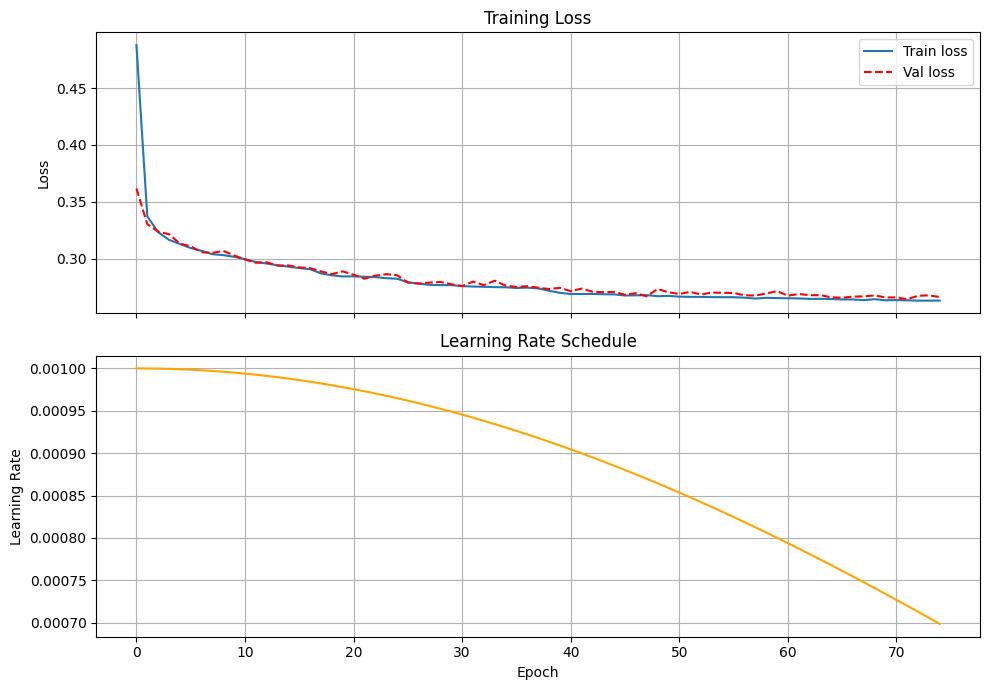

In [9]:
''' 
ENTRENAMIENTO DEL MODELO LATENT DIFFUSION
    se pueden configurar más elementos directamente en setup_latent_model 

'''
CHECKPOINT = False

from src.diffusion_setups.setup_latent import setup_latent_model


model, scheduler, trans = setup_latent_model(
    timesteps=1000, 
    emb_dim=256, 
    hidden_dims=512, 
    latent_dim=200, # siempre es 200 porque es el tamaño del vector del VAE
    deep=3, 
    increase_dims=False
)

model, scheduler, losses = train_latent(
    model=model,
    scheduler=scheduler,
    transform_data=trans,
    epochs=200,
    batch_size=2048//16,
    learning_rate=1e-3,
    resume=CHECKPOINT,
    source='encoder_latent'
)

# [EXTRA] Extract all VAE latents
Using the trained VAE, we can extract the latent representations of the audio samples in the dataset. This will allow us to train a diffusion model on these latent representations.

In [17]:
from src.models import VAE, AutoEncoder
from src.dataset import NSynth
from tqdm import tqdm 

def load_vae(input_height=1500, input_width=251, latent_dim=200, channels=[2,16,32,64], model_path=r"C:\Users\Articuno\Desktop\TFG-info\data\models\vae.pth"):
    model = VAE((input_height, input_width), latent_dim=latent_dim, channels=channels).to(device)
    model.load_state_dict(torch.load(model_path))
    model.eval()
    print("VAE Loaded")
    return model

def load_encoder(input_height = 4000, input_width  = 201, latent_dim   = 200, channels = [2, 16, 32, 64], model_path=r"C:\Users\Articuno\Desktop\TFG-info\data\models\autoencoder_fase.pth"):
    model = AutoEncoder((input_height, input_width), latent_dim, channels).to(device)
    model.load_state_dict(torch.load(model_path))
    model.eval()
    print("Encoder Loaded")
    return model

def extract_latents(model, dataset, stft_transform, variational=True):
    dataloader = DataLoader(dataset, batch_size=1, shuffle=False)
    all_z = []
    pbar = tqdm(dataloader, desc="Extracting latents")
    with torch.no_grad():
        for waveform, _, _, _ in pbar:
            waveform = waveform.to(device)
            stft_spec = stft_transform(waveform)
            # log_mag, sin, cos = compute_magnitude_and_phase_sin_cos(stft_spec)
            # x = torch.cat([log_mag, sin, cos], dim=1).to(device)
            log_mag, phase = compute_magnitude_and_phase(stft_spec)
            x = torch.cat([log_mag, phase], dim=1).to(device)
            if variational:
                feat, mu, logvar = model.encoder(x)
                z = mu # TODO no se lo que hace esto
            else:
                z = model.encoder(x)
            # z = model.reparameterize(mu, logvar) # TODO no se lo que hace esto
            all_z.append(z.cpu())
    all_z = torch.cat(all_z, dim=0)    
    return all_z    

In [ ]:
# extract_latents una sola vez
n_fft = 1500 # DISMINUIR TAMAÑO PARA OPTIMIZAR
hop_length = 250
win_length = n_fft

mode = 'validation'

stft_transform = T.Spectrogram(
    n_fft=n_fft, win_length=win_length, hop_length=hop_length,
    power=None, onesided=False, center=False
).to(device)
latents = extract_latents(load_vae(), NSynth(mode), stft_transform)

# Calcula media y std del dataset de latentes
latent_mean = latents.mean()
latent_std = latents.std()
latents_norm = (latents - latent_mean) / latent_std  # que tengan distribución ~N(0,1)
torch.save({'mean': latent_mean, 'std': latent_std}, paths['latent'][f'{mode}_norm_params'])
torch.save(latents_norm, paths['latent'][f'dataset_{mode}'])

# [EXTRA] Extract all Encoder Latents

In [ ]:
mode = 'training'


n_fft = 4000 # Small n_fft: good time resolution, poor frequency resolution. Large n_fft: good frequency resolution, poor time resolution.
hop_length = 300
win_length = n_fft  # Same as n_fft

# Apply the correct transform for magnitude and phase (onesided=False to handle complex spectrogram)
stft_transform = T.Spectrogram(
    n_fft=n_fft,
    win_length=win_length,
    hop_length=hop_length,
    power=None,  # Keep as complex spectrogram (magnitude and phase)
    onesided=False,  # Make sure we keep the full spectrum (complex-valued)
    center=False
).to(device)

latents = extract_latents(load_encoder(), NSynth(mode), stft_transform, variational=False)

# Calcula media y std del dataset de latentes
latent_mean = latents.mean()
latent_std = latents.std()
latents_norm = (latents - latent_mean) / latent_std  # que tengan distribución ~N(0,1)
torch.save({'mean': latent_mean, 'std': latent_std}, paths['encoder_latent'][f'{mode}_norm_params'])
torch.save(latents_norm, paths['encoder_latent'][f'dataset_{mode}'])

Encoder Loaded


Extracting latents: 100%|██████████| 289205/289205 [10:15<00:00, 470.13it/s]


In [21]:
mode = 'validation'

n_fft = 4000 # Small n_fft: good time resolution, poor frequency resolution. Large n_fft: good frequency resolution, poor time resolution.
hop_length = 300
win_length = n_fft  # Same as n_fft

# Apply the correct transform for magnitude and phase (onesided=False to handle complex spectrogram)
stft_transform = T.Spectrogram(
    n_fft=n_fft,
    win_length=win_length,
    hop_length=hop_length,
    power=None,  # Keep as complex spectrogram (magnitude and phase)
    onesided=False,  # Make sure we keep the full spectrum (complex-valued)
    center=False
).to(device)

latents = extract_latents(load_encoder(), NSynth(mode), stft_transform, variational=False)

# Calcula media y std del dataset de latentes
latent_mean = latents.mean()
latent_std = latents.std()
latents_norm = (latents - latent_mean) / latent_std  # que tengan distribución ~N(0,1)
torch.save({'mean': latent_mean, 'std': latent_std}, paths['encoder_latent'][f'{mode}_norm_params'])
torch.save(latents_norm, paths['encoder_latent'][f'dataset_{mode}'])

Encoder Loaded


Extracting latents: 100%|██████████| 12678/12678 [01:33<00:00, 135.84it/s]
